In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import statsmodels.api as sm

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

plt.style.use("default")

sns.set_theme(
    style="whitegrid"
)

In [3]:
model_df = pd.read_csv(
    "../data/processed/model_dataset.csv"
)

In [4]:
features = [
    "elo_diff",

    "home_form_5",
    "away_form_5",

    "home_avg_goals_5",
    "away_avg_goals_5",

    "home_avg_conceded_5",
    "away_avg_conceded_5",

    "home_avg_goal_diff_5",
    "away_avg_goal_diff_5"
]

In [5]:
X = model_df[features]

y = model_df["home_score"]

In [6]:
X = sm.add_constant(X)

In [7]:
# Divición 80% Entrenamiento y 20% Prueba
# Sirve para evaluar el modelo con partidos nunca vistos.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [9]:
# Entrenamiento con Regresion de Poisson (goles esperados)
poisson_model = sm.GLM(
    y_train,
    X_train,
    family=sm.families.Poisson()
)

poisson_results = poisson_model.fit()

In [21]:
poisson_results.params.sort_values()

away_avg_goal_diff_5   -0.048616
home_form_5            -0.017053
elo_diff                0.002111
away_form_5             0.004748
home_avg_conceded_5     0.024220
home_avg_goal_diff_5    0.046789
home_avg_goals_5        0.071008
away_avg_goals_5        0.082610
const                   0.097795
away_avg_conceded_5     0.131226
dtype: float64

In [10]:
print(
    poisson_results.summary()
)

                 Generalized Linear Model Regression Results                  
Dep. Variable:             home_score   No. Observations:                18339
Model:                            GLM   Df Residuals:                    18331
Model Family:                 Poisson   Df Model:                            7
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -30865.
Date:                Thu, 25 Jun 2026   Deviance:                       24853.
Time:                        22:24:41   Pearson chi2:                 2.35e+04
No. Iterations:                     5   Pseudo R-squ. (CS):             0.2958
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.0978 

In [18]:
# Calcula los goles esperados para cada partido del conjunto de prueba.
y_pred = poisson_results.predict(
    X_test
)

In [12]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

MAE: 1.2092
RMSE: 1.7915


In [13]:
comparison = pd.DataFrame({
    "Real": y_test.values,
    "Predicho": y_pred
})

comparison.head(20)

,Real,Predicho
6293,2,1.946918
19213,1,1.857612
1635,1,1.206814
4013,3,1.424091
259,2,1.996786
18151,0,1.491127
5135,2,1.180806
2797,5,4.656334
16420,2,1.589185
4525,0,1.548974


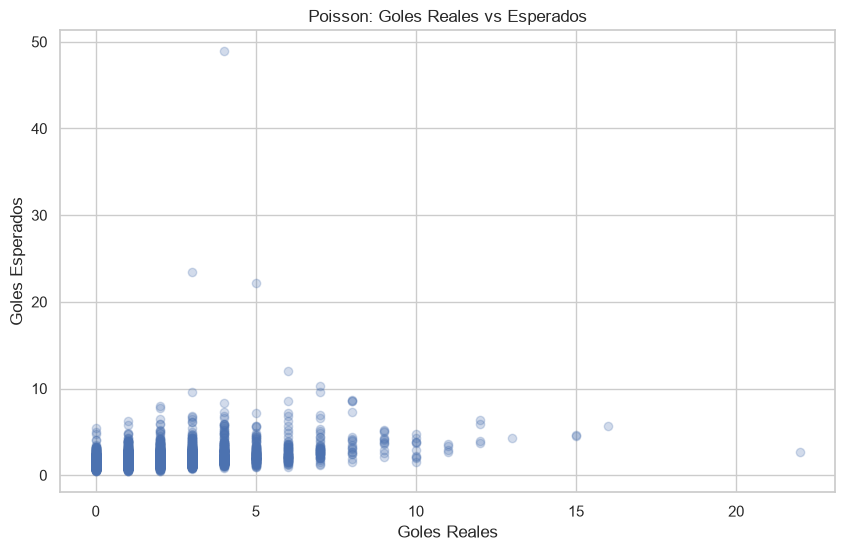

In [14]:
# para comprobar que el modelo produce aproximadamente la misma distribución de goles que existe en la realidad.
plt.figure(figsize=(10,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.25
)

plt.xlabel("Goles Reales")
plt.ylabel("Goles Esperados")

plt.title(
    "Poisson: Goles Reales vs Esperados"
)

plt.show()

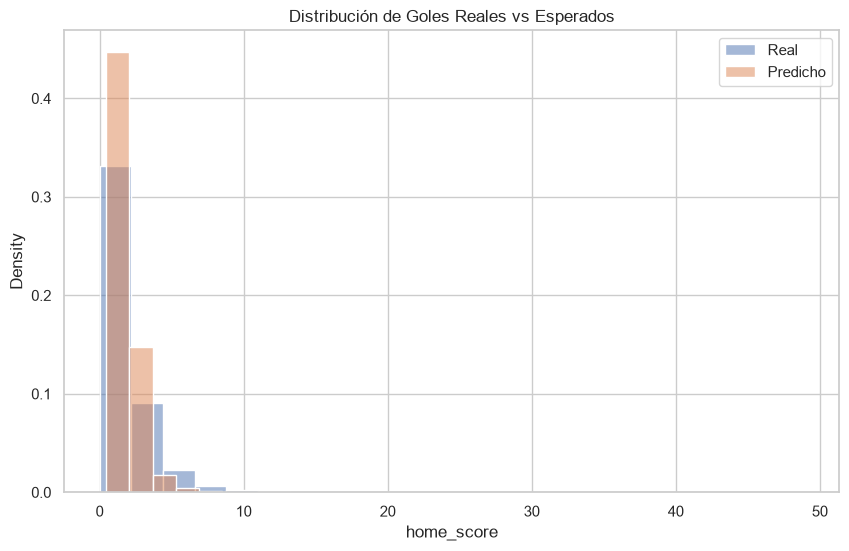

In [15]:
plt.figure(figsize=(10,6))

sns.histplot(
    y_test,
    stat="density",
    bins=10,
    label="Real",
    alpha=0.5
)

sns.histplot(
    y_pred,
    stat="density",
    bins=30,
    label="Predicho",
    alpha=0.5
)

plt.legend()

plt.title(
    "Distribución de Goles Reales vs Esperados"
)

plt.show()

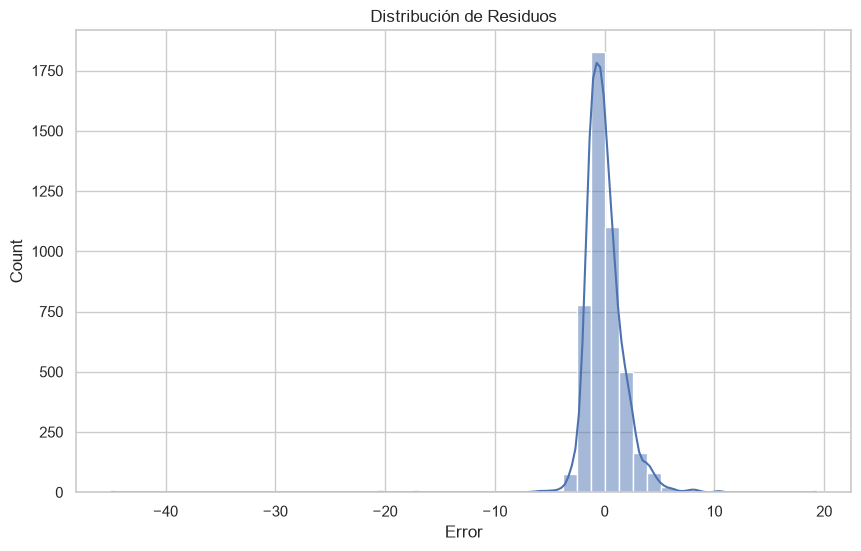

In [19]:
# Distribución de residuos. Error = Real - Predicho.
# Idealmente en 0 -> eso significa que no tiene sesgo
residuals = y_test - y_pred

plt.figure(figsize=(10,6))

sns.histplot(
    residuals,
    bins=50,
    kde=True
)

plt.title(
    "Distribución de Residuos"
)

plt.xlabel(
    "Error"
)

plt.show()

In [17]:
# Akaike Information Criterion. Sirve para comparar modelos.
poisson_results.aic

np.float64(61746.293530176175)

In [20]:
model_df.info()

model_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 22924 entries, 0 to 22923
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date                  22924 non-null  str    
 1   home_team             22924 non-null  str    
 2   away_team             22924 non-null  str    
 3   home_score            22924 non-null  int64  
 4   away_score            22924 non-null  int64  
 5   tournament            22924 non-null  str    
 6   city                  22924 non-null  str    
 7   country               22924 non-null  str    
 8   neutral               22924 non-null  bool   
 9   home_elo              22924 non-null  float64
 10  away_elo              22924 non-null  float64
 11  elo_diff              22924 non-null  float64
 12  match_id              22924 non-null  int64  
 13  home_form_5           22924 non-null  float64
 14  home_avg_goals_5      22924 non-null  float64
 15  home_avg_conceded_5   22924 no

,home_score,away_score,home_elo,away_elo,elo_diff,match_id,home_form_5,home_avg_goals_5,home_avg_conceded_5,home_avg_goal_diff_5,away_form_5,away_avg_goals_5,away_avg_conceded_5,away_avg_goal_diff_5,goal_difference
count,22924.000000,22924.000000,22924.000000,22924.000000,22924.000000,22924.000000,22924.000000,22924.000000,22924.000000,22924.000000,22924.000000,22924.000000,22924.000000,22924.000000,22924.000000
mean,1.830571,1.244678,1543.092666,1534.922407,8.170259,17481.890944,7.003882,1.581657,1.536668,0.044989,6.850724,1.547463,1.587188,-0.039725,0.585893
std,1.809420,1.446340,124.581578,123.740094,137.999472,12705.272071,3.610349,0.947600,1.066459,1.546114,3.619367,0.943396,1.127638,1.598282,2.442140
min,0.000000,0.000000,1037.318348,1066.994904,-640.198807,1.000000,0.000000,0.000000,0.000000,-24.000000,0.000000,0.000000,0.000000,-21.000000,-21.000000
25%,1.000000,0.000000,1461.789608,1457.117203,-78.860365,6830.750000,4.000000,1.000000,0.800000,-0.800000,4.000000,1.000000,0.800000,-0.800000,-1.000000
50%,1.000000,1.000000,1536.686316,1532.022772,7.282643,15052.500000,7.000000,1.400000,1.400000,0.200000,7.000000,1.400000,1.400000,0.000000,0.000000
75%,3.000000,2.000000,1625.041246,1619.376443,96.152131,26211.000000,10.000000,2.000000,2.000000,1.000000,10.000000,2.000000,2.000000,0.800000,2.000000
max,22.000000,21.000000,2013.462936,2021.807600,798.545200,49403.000000,15.000000,13.600000,24.000000,13.600000,15.000000,21.000000,21.000000,21.000000,22.000000


In [22]:
with open(
    "../models/poisson_model.pkl",
    "wb"
) as f:

    pickle.dump(
        poisson_results,
        f
    )

In [23]:
with open(
    "../models/poisson_features.pkl",
    "wb"
) as f:

    pickle.dump(features,f)